# Within-cell-type expression variation — Figures 4E, 4F, S5G

Path2Space predicts spatial gene expression from H&E histology. Beyond
predicting *which* cell types are present, this notebook asks whether the
predictions resolve expression variation **within** individual cell types.

The agreement between predicted and measured expression is measured
gene-by-gene inside regions that share a cell-type identity, defined two ways:

- **Pathologist-annotated regions** (Figure 4E) — cancer, stromal and
  lymphocyte areas outlined by a pathologist on the HEST validation slides.
- **Transcriptomic neighborhoods** (Figure 4F) — spatially coherent regions
  grouped by their dominant deconvolved cell type.

Figure S5G then checks whether genes that are well predicted in one cell type
are also well predicted in another — the concordance of gene-wise accuracy.

## Method

For each region, the per-gene Pearson correlation between predicted and
measured expression is computed across the region's spots (Stage A — see the
[README](../README.md); the primitive is `gene_pearson` in
[`lib/cell_type_corr.py`](../lib/cell_type_corr.py)). Those per-gene
correlations, aggregated to one value per (cell type, gene), are bundled in
`data/` and loaded below.

This notebook runs Stage B: per-cell-type median correlation and the number
of genes exceeding PCC > 0.4 (`summarize_by_cell_type`), and the pairwise
concordance of gene-wise accuracy across cell types (`concordance_matrix`).

## Setup

In [1]:
import sys; sys.path.insert(0, "../lib")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from cell_type_corr import summarize_by_cell_type, concordance_matrix

## Load the per-gene correlation tables

One row per (cell type, gene): the Pearson correlation between predicted and
measured expression for that gene within that cell type's regions.

In [2]:
pathologist   = pd.read_parquet("../data/pathologist_region_correlations.parquet")
neighborhoods = pd.read_parquet("../data/neighborhood_correlations.parquet")

print(f"pathologist regions : {len(pathologist):,} rows, "
      f"{pathologist['cell_type'].nunique()} cell types")
print(f"neighborhoods       : {len(neighborhoods):,} rows, "
      f"{neighborhoods['cell_type'].nunique()} cell types")
pathologist.head()

pathologist regions : 48,000 rows, 4 cell types
neighborhoods       : 68,156 rows, 5 cell types


,cell_type,gene,correlation
0,All,A1BG,0.101310
1,Cancer,A1BG,0.163689
2,Lympho.,A1BG,-0.145267
3,Stromal,A1BG,0.075330
4,All,A2M,0.313414


## Plot helpers

In [3]:
def plot_cell_type_pcc(df, title, threshold=0.4):
    """Box plot of per-gene PCC per cell type, ordered by median."""
    order = (df.groupby("cell_type")["correlation"].median()
               .sort_values(ascending=False).index.tolist())
    fig, ax = plt.subplots(figsize=(0.95 * len(order) + 1.5, 3.2))
    sns.boxplot(data=df, x="cell_type", y="correlation", order=order,
                showfliers=False, width=0.6, color="#9ecae1", ax=ax)
    ax.axhline(threshold, ls="--", lw=0.8, color="grey")
    for i, ct in enumerate(order):
        m = df.loc[df.cell_type == ct, "correlation"].median()
        ax.text(i, m + 0.03, f"{m:.2f}", ha="center", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("Pearson r (predicted vs measured)")
    ax.set_title(title, fontsize=9)
    sns.despine()
    fig.tight_layout(); plt.show()


def plot_concordance(cmat, title):
    """Lower-triangle heatmap of the cell-type concordance matrix."""
    fig, ax = plt.subplots(figsize=(0.55 * len(cmat) + 1.8, 0.55 * len(cmat) + 1.2))
    mask = np.triu(np.ones_like(cmat, dtype=bool), k=1)
    sns.heatmap(cmat, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=0.2, vmax=1.0, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.6}, annot_kws={"fontsize": 7}, ax=ax)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_title(title, fontsize=9)
    fig.tight_layout(); plt.show()

## Figure 4E — pathologist-annotated regions

Median predicted-vs-measured PCC per pathologist-annotated cell type, and the
number of genes predicted at PCC > 0.4. `All` is the whole-tissue reference.

In [4]:
path_summary = summarize_by_cell_type(pathologist, value="correlation")
path_summary

,median_pcc,n_genes_over_threshold,n_genes
cell_type,,,
All,0.394936,5894,12000
Cancer,0.388544,5774,12000
Stromal,0.299122,3286,12000
Lympho.,0.267112,3619,12000


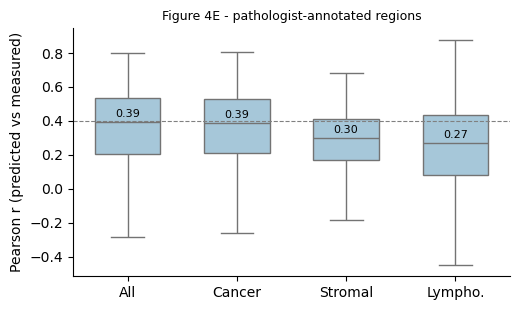

In [5]:
plot_cell_type_pcc(pathologist, "Figure 4E - pathologist-annotated regions")

In [6]:
for ct, r in path_summary.iterrows():
    print(f"  {ct:9s}  median PCC = {r['median_pcc']:.2f}   "
          f"genes with PCC > 0.4: {int(r['n_genes_over_threshold']):,}")

  All        median PCC = 0.39   genes with PCC > 0.4: 5,894
  Cancer     median PCC = 0.39   genes with PCC > 0.4: 5,774
  Stromal    median PCC = 0.30   genes with PCC > 0.4: 3,286
  Lympho.    median PCC = 0.27   genes with PCC > 0.4: 3,619


## Figure 4F — transcriptomic neighborhoods

The same measurement inside spatially coherent neighborhoods, grouped by their
dominant deconvolved cell type.

In [7]:
nb_summary = summarize_by_cell_type(neighborhoods, value="correlation")
nb_summary

,median_pcc,n_genes_over_threshold,n_genes
cell_type,,,
Cancer,0.293592,2671,14068
Macrophage,0.282574,2449,14068
T cell,0.233680,2250,11884
B cell,0.204235,2079,14068
CAF,0.188758,2,14068


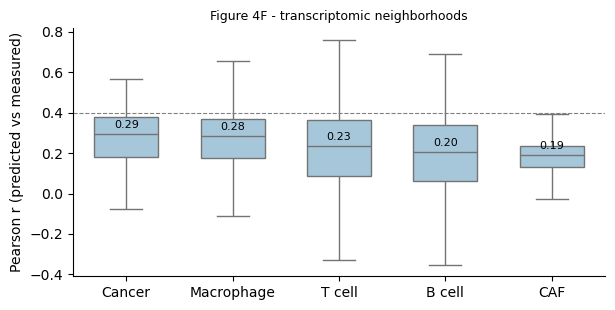

In [8]:
plot_cell_type_pcc(neighborhoods, "Figure 4F - transcriptomic neighborhoods")

In [9]:
for ct, r in nb_summary.iterrows():
    print(f"  {ct:11s}  median PCC = {r['median_pcc']:.2f}   "
          f"genes with PCC > 0.4: {int(r['n_genes_over_threshold']):,}")

  Cancer       median PCC = 0.29   genes with PCC > 0.4: 2,671
  Macrophage   median PCC = 0.28   genes with PCC > 0.4: 2,449
  T cell       median PCC = 0.23   genes with PCC > 0.4: 2,250
  B cell       median PCC = 0.20   genes with PCC > 0.4: 2,079
  CAF          median PCC = 0.19   genes with PCC > 0.4: 2


## Figure S5G — concordance of gene-wise accuracy

Pivot each table to a genes x cell-type matrix of correlations, then correlate
the columns: a high value means a gene well predicted in one cell type tends
to be well predicted in another. High concordance indicates the predictions
share a transcriptome-wide accuracy structure rather than per-cell-type
idiosyncrasies.

In [10]:
conc_path = concordance_matrix(pathologist)
conc_nb   = concordance_matrix(neighborhoods)
conc_nb.round(2)

cell_type,B cell,CAF,Cancer,Macrophage,T cell
cell_type,,,,,
B cell,1.00,0.52,0.56,0.46,0.23
CAF,0.52,1.00,0.80,0.61,0.45
Cancer,0.56,0.80,1.00,0.70,0.54
Macrophage,0.46,0.61,0.70,1.00,0.28
T cell,0.23,0.45,0.54,0.28,1.00


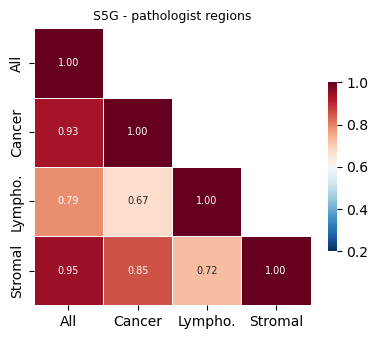

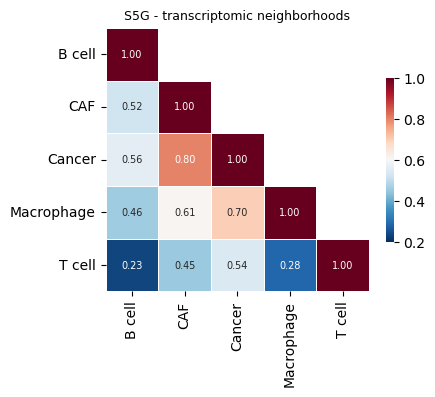

In [11]:
plot_concordance(conc_path, "S5G - pathologist regions")
plot_concordance(conc_nb,   "S5G - transcriptomic neighborhoods")

In [12]:
def offdiag_range(cmat):
    v = cmat.to_numpy()
    off = v[np.triu_indices_from(v, k=1)]
    return np.nanmin(off), np.nanmax(off)

for name, cmat in [("pathologist regions", conc_path),
                   ("transcriptomic neighborhoods", conc_nb)]:
    lo, hi = offdiag_range(cmat)
    print(f"  {name:30s}  pairwise gene-accuracy correlation: {lo:.2f} to {hi:.2f}")

  pathologist regions             pairwise gene-accuracy correlation: 0.67 to 0.95
  transcriptomic neighborhoods    pairwise gene-accuracy correlation: 0.23 to 0.80


### Reading the concordance range

Pathologist-region concordance spans **0.67–0.95**. Neighborhood concordance
spans **0.23–0.80** — the low values come from the **T cell** column: gene-wise
accuracy in T-cell neighborhoods is only weakly concordant with accuracy in
B-cell or macrophage neighborhoods. The T cell neighborhood is present only in
the corrected five-cell-type table used here; an earlier four-cell-type
neighborhood table (Cancer, Macrophage, B cell, CAF — see the
[README](../README.md) reproduction note) lacks the T cell column and spans a
tighter 0.52–0.85.

## Save the summary tables

In [13]:
path_summary.to_pickle("../data/pathologist_summary.pkl")
nb_summary.to_pickle("../data/neighborhood_summary.pkl")
print("wrote ../data/pathologist_summary.pkl")
print("wrote ../data/neighborhood_summary.pkl")

wrote ../data/pathologist_summary.pkl
wrote ../data/neighborhood_summary.pkl


## Takeaway

Inside pathologist-annotated regions and transcriptomic neighborhoods alike,
predicted and measured expression remain positively correlated for thousands
of genes per cell type, and the gene-wise accuracy is concordant across cell
types. Path2Space resolves expression variation *within* a cell type, not
only the variation that distinguishes one cell type from another.